# Metabolitics - Starters Guide

Welcome to the installation and environment setup guide for Metabolitics algorithm tool proposed in https://ieeexplore.ieee.org/document/9137659 by Ali Çakmak and Hasan Çelik, and developped by other researchers.

Metabolitics employs flux variability analysis with a dynamically built objective function based on
biofluid metabolomics measurements in a personalized manner. Moreover, Metabolitics builds supervised classification models to discriminate between patients and healthy subjects based on the computed metabolic network changes.

## Cloning the repository
After getting your access to ITU Bioinformatics & Database Lab Organisation on Github clone the "metabolitics-dev" repository.

(If you don't have git on your system download and install from https://git-scm.com/downloads)

(You may want to work on your version of metabolitics, delete `.git` folder, later create your own.)
```
git clone https://github.com/itu-bioinformatics-database-lab/metabolitics-dev.git
```

## Installing required libraries
* Based on your Python distribution install required libraries except "cobra".\
__Example__: `pip install -U scikit-learn` or `conda install scikit-learn`\
(You can also download libraries using Anaconda Navigator GUI)(Or installing the requirements.txt)
* Library "cobra" should be locally imported. If it is installed on your main environment, delete it.\
(`pip uninstall cobra` or `conda uninstall --force cobra`)
* Make sure "cobra" library is in the metabolitics directory.

## Create your virtual environment for metabolitics using `metaboliticsenv.yml` file

Create the virtual environment from the `metaboliticsenv.yml` file:
```
conda env create -f metaboliticsenv.yml
```

Delete a specific environment:
```
conda env remove --name name_of_the_environment
```

## Installing IBM CPLEX as an alternative solver
* To download CPLEX Optimization Studio first create an account using your academic ITU e-mail.(https://www.ibm.com/tr-tr/products/ilog-cplex-optimization-studio)
* Once your account is confirmed go to https://www.ibm.com/academic/topic/data-science and download the software for your OS.
* You may have to install "IBM Download Director" first, from https://www-03.ibm.com/isc/esd/dswdown/dldirector/installation_en.html.
(If the file doesn't open, you may need to install Java first. Go to https://java.com to download and install the latest version of Java.)
* After the instalation has completed, you need to link CPLEX with Python.
* Go to the instalation directory of IBM CPLEX, in my case: `C:\Program Files\IBM\ILOG\CPLEX_Studio201\python`
* Open an administrator shell inside of the directory.
* Switch to your `metaboliticsenv`. First type `conda deactivate` to close the base environment. Then `conda activate metaboliticsenv`.
* If you can't switch between environments in Windows Powershell type `conda init powershell` to change setting.(You should see the name of the environment on the left, inside braces)
* Run `setup.py` with `python setup.py install` command in an administrator shell.
* In the `analysis/analysis.py` you may use `self.model.solver = "cplex"` line to change for different solvers.
```python
def __init__(self, model, without_transports=True, timeout=10 * 60):
        '''
        :param model: cobra Model
        '''
        self.model = load_network_model(model)
        self.model.solver = "cplex"
        # self.model.solver = "glpk"
        self.without_transports = without_transports
```

## Sample Run - Breast Cancer Report (2 healthy and 2 patient with kfold=2)

In [3]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', '{:.2g}'.format)

In [5]:
from sklearn_utils.utils import SkUtilsIO

X_breast, y_breast = SkUtilsIO("datasets/disease_datasets/Breast_Cancer_v3_2patient_2healthy.csv").from_csv(label_column='Factors')

In [6]:
from preprocessing.metabolitics_pipeline import MetaboliticsPipeline

from utils import load_metabolite_mapping
from sklearn_utils.preprocessing import FeatureRenaming

MetaboliticsPipeline.steps['metabolite-name-mapping'] = FeatureRenaming(load_metabolite_mapping("synonym"))

transformer_pipe = MetaboliticsPipeline([
    "metabolite-name-mapping",
    "fold-change-scaler",
    "metabolitics-transformer"
])

X_breast_transformed = transformer_pipe.fit_transform(X=X_breast, y=y_breast)

/home/canfedora/workspace/itu-bioinformatics-projects/metabolitics-dev/cobra/core/dictlist.py:214: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if current_length is 0:


### Data after Flux Analysis Step

In [8]:
X_breast_transformed

[{'24_25DHVITD3tm_max': 2.1422747754295415,
  '24_25DHVITD3tm_min': 0.0,
  '25HVITD3t_max': 4.284549550859083,
  '25HVITD3t_min': 0.0,
  'COAtl_max': 1000.0,
  'COAtl_min': 992.6571825695432,
  'EX_5adtststerone_e_max': 1000.0,
  'EX_5adtststerone_e_min': -1000.0,
  'EX_5adtststerones_e_max': 1000.0,
  'EX_5adtststerones_e_min': -1000.0,
  'EX_5fthf_e_max': 0.0,
  'EX_5fthf_e_min': -1000.0,
  'EX_5htrp_e_max': 2.5780658546832456,
  'EX_5htrp_e_min': 0.0,
  'EX_5mthf_e_max': 1000.0,
  'EX_5mthf_e_min': -1000.0,
  'EX_5thf_e_max': 1000.0,
  'EX_5thf_e_min': -1000.0,
  'EX_6dhf_e_max': 1000.0,
  'EX_6dhf_e_min': -1000.0,
  '24_25VITD3Hm_max': 2.1422747754135116,
  '24_25VITD3Hm_min': 0.0,
  '24NPHte_max': 0.0,
  '24NPHte_min': -4.284549550585211,
  '10FTHF7GLUtl_max': 2.667774748327105,
  '10FTHF7GLUtl_min': 0.0,
  '10FTHFtm_max': 1000.0,
  '10FTHFtm_min': -1000.0,
  '11DOCRTSLtr_max': 0.0,
  '11DOCRTSLtr_min': -1.0628122473424355,
  '13DAMPPOX_max': 3.3949364719524624,
  '13DAMPPOX_min':

In [9]:
diff_score_pipe = MetaboliticsPipeline([
        'reaction-diff', 
        'feature-selection', 
        'pathway-transformer', 
        'transport-pathway-elimination'
    ])

X_breast_pathways = diff_score_pipe.fit_transform(X=X_breast_transformed, y=y_breast)

### Data after Diff Score Step

In [7]:
X_breast_pathways

[{'Extracellular exchange': 598.9291772596389,
  'Lysine metabolism': 1961.185620046859,
  'Tryptophan metabolism': 971.3059518123478,
  'Steroid metabolism': 1.4610836669759522,
  'Valine, leucine, and isoleucine metabolism': 989.2509564435537,
  'Fatty acid oxidation': 1190.2344889480846,
  'Nucleotide interconversion': 7.825569087517749,
  'Arginine and proline metabolism': -1835.7626754879961,
  'Alanine and aspartate metabolism': 1987.355337204227,
  'Bile acid synthesis': 1.4610836669992484,
  'Cholesterol metabolism': 344.78853306115104,
  'Fatty acid synthesis': 1252.589243333565,
  'Vitamin A metabolism': 1.4610836670914864,
  'Purine catabolism': -3.189605320976227,
  'Intracellular source/sink': 1967.563783025398,
  'Drug metabolism': 1.4610836669713965},
 {'Extracellular exchange': 592.5713294438393,
  'Lysine metabolism': 1964.4353954616424,
  'Tryptophan metabolism': 971.3059518123478,
  'Steroid metabolism': 1.795672272991368,
  'Valine, leucine, and isoleucine metabolis

In [9]:
from sklearn_utils.utils import feature_importance_report

df = feature_importance_report(X_breast_pathways, y_breast)

df

labels,c,healthy,F,pval
Alanine and aspartate metabolism,2e+03,0,6.6e+04,0.00024
"Valine, leucine, and isoleucine metabolism",9.9e+02,0,8.9e+03,0.0006
Fatty acid oxidation,1.2e+03,1.2e+02,9.8e+03,0.0006
Extracellular exchange,6e+02,3.9e+02,2.7e+03,0.0015
Tryptophan metabolism,9.7e+02,0,1.3e+03,0.0024
Fatty acid synthesis,1.3e+03,0,1e+03,0.0027
Arginine and proline metabolism,-1.8e+03,5.7e-14,7e+02,0.0033
Intracellular source/sink,2e+03,1.9e+03,2.6e+02,0.0077
Lysine metabolism,2e+03,1.9e+03,1.9e+02,0.0092
Purine catabolism,-3.4,0,1.4e+02,0.011


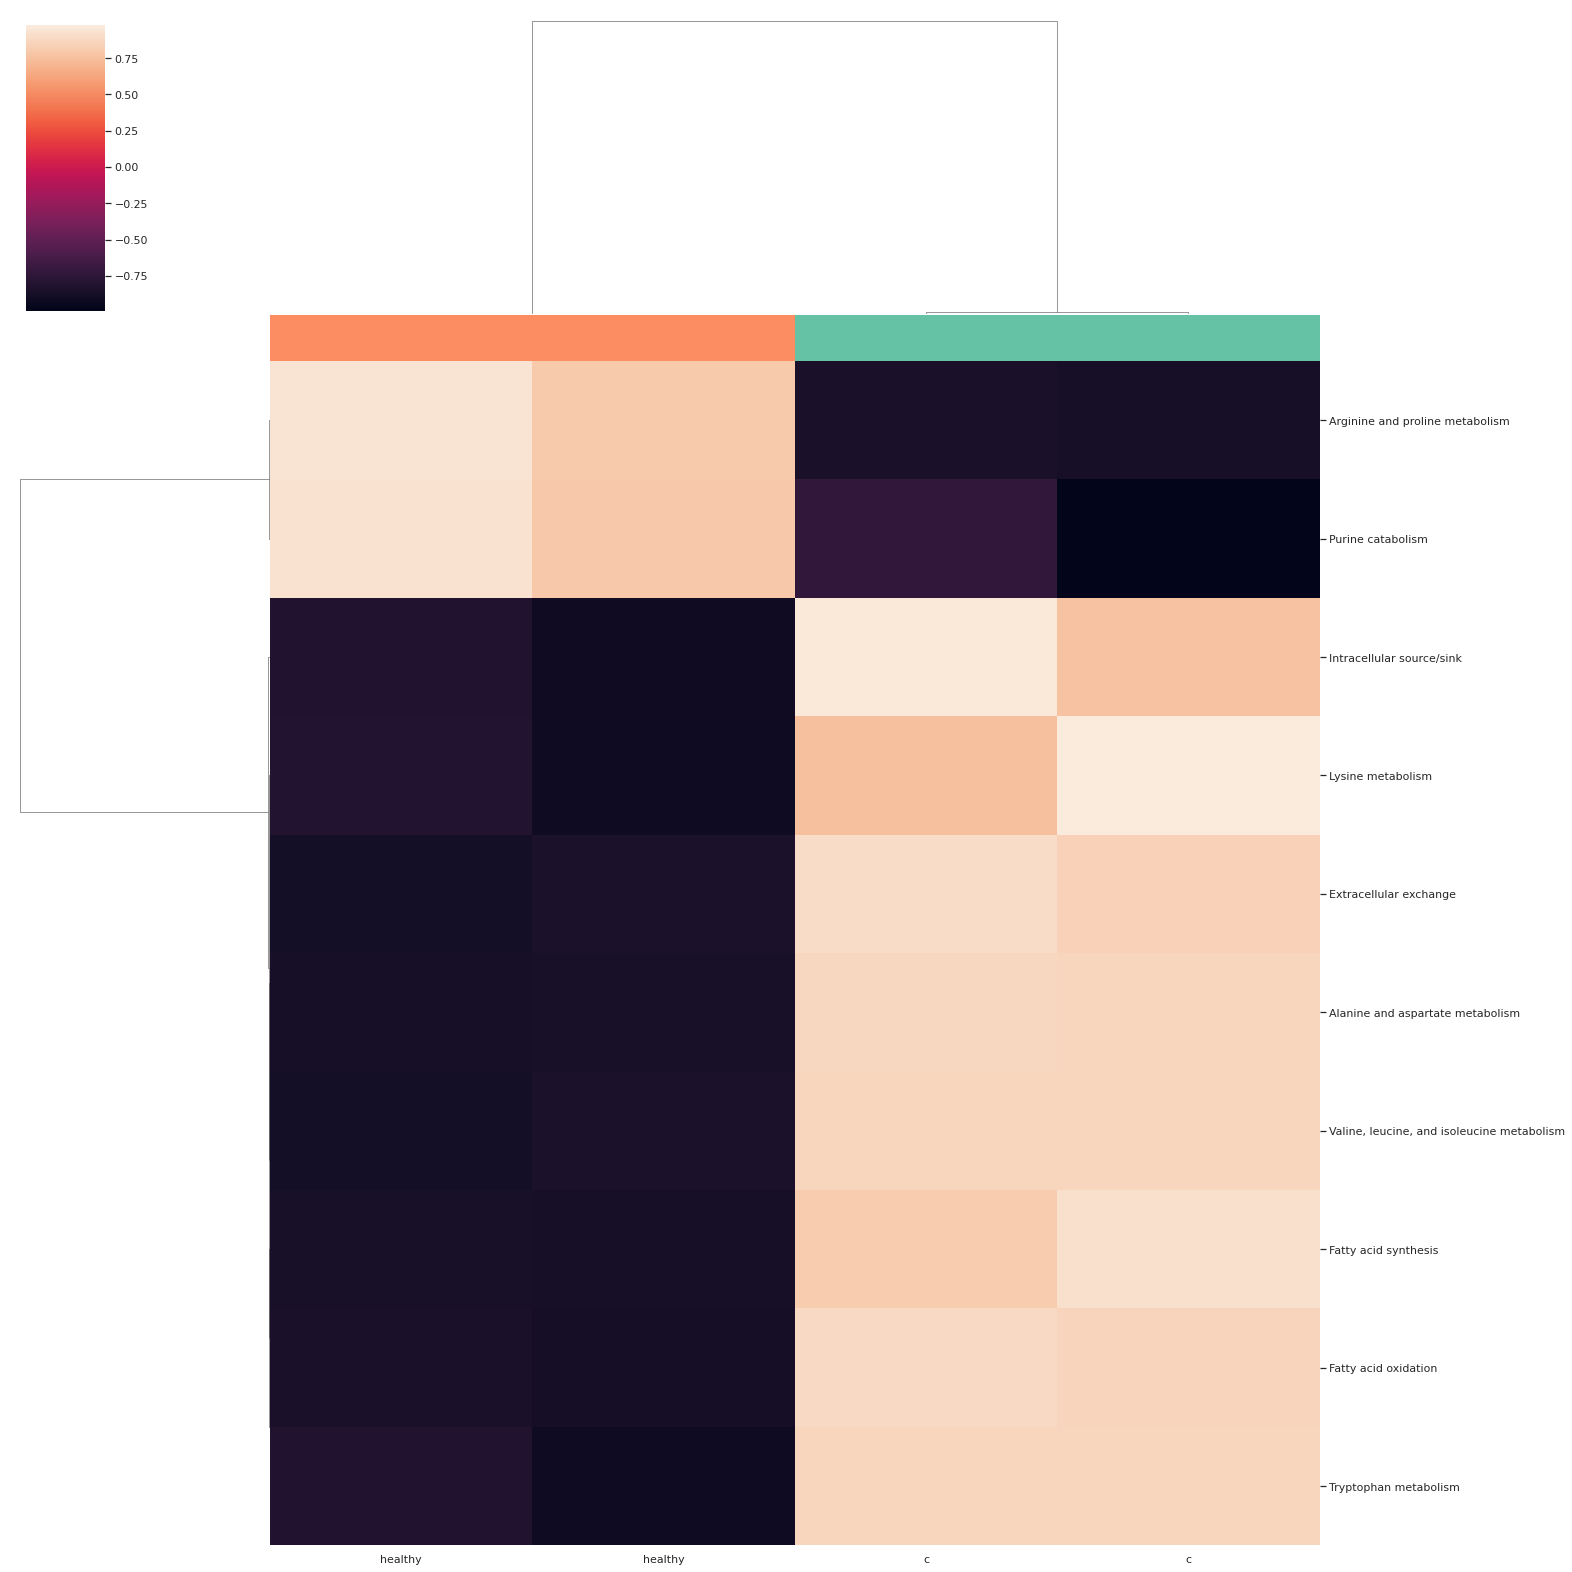

In [10]:
from sklearn_utils.visualization import plot_heatmap

plot_heatmap(X_breast_pathways, y_breast)

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

ml_pipeline = Pipeline([
            ('vect', DictVectorizer(sparse=False)),
            ('pca', PCA()),
            ('clf', LogisticRegression(C=0.3e-6, random_state=43))
        ])

In [12]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

kf = StratifiedKFold(n_splits=2, shuffle=True, random_state=43)

scores = cross_val_score(ml_pipeline, X_breast_pathways, y_breast, cv=kf, n_jobs=None, scoring='f1_micro')
print(f'K-Fold test: {scores}')
print(f'Mean: {scores.mean().round(3)}')
print(f'Std: {scores.std().round(3)}')

K-Fold test: [1. 1.]
Mean: 1.0
Std: 0.0
